# Dataset Quality Check

In [34]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(
        f"Could not find src directory at: {PROJECT_ROOT / 'src'}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src directory:", PROJECT_ROOT / "src")

Project root: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction
src directory: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\src


In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent.resolve()

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

df = pd.read_csv(FEATURES_PATH)

print("Dataset path:")
print(FEATURES_PATH)

print("\nShape:")
print(df.shape)

print("\nNumber of subjects:")
print(df["subject_id"].nunique())

print("\nFirst 5 rows:")
display(df.head())

Dataset path:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\data\features\sleep_edf_features.csv

Shape:
(456640, 16)

Number of subjects:
197

First 5 rows:


,subject_id,epoch_index,start_time,end_time,raw_stage,target_stage,delta_absolute,theta_absolute,alpha_absolute,beta_absolute,delta_relative,theta_relative,alpha_relative,beta_relative,spectral_entropy,dominant_frequency
0,SC4001,0,0.0,30.0,Sleep stage W,W,4.440571e-10,9.889418e-11,8.991909e-12,1.013694e-11,0.790025,0.175943,0.015998,0.018035,0.667405,0.585938
1,SC4001,1,30.0,60.0,Sleep stage W,W,2.597151e-10,4.180098e-11,1.341957e-11,2.940132e-11,0.754247,0.121396,0.038972,0.085385,0.755591,1.074219
2,SC4001,2,60.0,90.0,Sleep stage W,W,3.779352e-10,2.401454e-11,1.257038e-11,1.754188e-11,0.874724,0.055581,0.029094,0.040600,0.604871,1.171875
3,SC4001,3,90.0,120.0,Sleep stage W,W,2.028651e-10,1.827274e-11,1.337502e-11,7.659840e-12,0.837688,0.075453,0.055229,0.031630,0.656860,1.660156
4,SC4001,4,120.0,150.0,Sleep stage W,W,1.260171e-10,4.473053e-11,9.939413e-12,6.435664e-12,0.673446,0.239044,0.053117,0.034393,0.715088,2.050781


In [2]:
print("Columns:")
for column in df.columns:
    print(f"  - {column}")

Columns:
  - subject_id
  - epoch_index
  - start_time
  - end_time
  - raw_stage
  - target_stage
  - delta_absolute
  - theta_absolute
  - alpha_absolute
  - beta_absolute
  - delta_relative
  - theta_relative
  - alpha_relative
  - beta_relative
  - spectral_entropy
  - dominant_frequency


In [3]:
print("Epochs per subject:")
print(
    df.groupby("subject_id")
      .size()
      .describe()
)

print("\nSubjects by dataset:")
print(
    df["subject_id"]
      .str[:2]
      .value_counts()
)

Epochs per subject:
count     197.000000
mean     2317.969543
std       745.104984
min       671.000000
25%      2342.000000
50%      2710.000000
75%      2780.000000
max      2880.000000
dtype: float64

Subjects by dataset:
subject_id
SC    414659
ST     41981
Name: count, dtype: int64


**Missing and infinite values**

In [4]:
feature_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",
    "spectral_entropy",
    "dominant_frequency",
]

print("NaN values:")
print(
    df[feature_columns]
    .isna()
    .sum()
)

print("\nTotal NaN values:")
print(
    df[feature_columns]
    .isna()
    .sum()
    .sum()
)

print("\nInfinite values:")
print(
    df[feature_columns]
    .isin(
        [float("inf"), float("-inf")]
    )
    .sum()
    .sum()
)

NaN values:
delta_absolute        0
theta_absolute        0
alpha_absolute        0
beta_absolute         0
delta_relative        0
theta_relative        0
alpha_relative        0
beta_relative         0
spectral_entropy      0
dominant_frequency    0
dtype: int64

Total NaN values:
0

Infinite values:
0


**Check target labels**

In [5]:
print("Unique target stages:")
print(
    sorted(
        df["target_stage"]
        .unique()
    )
)

print("\nTarget-stage distribution:")
print(
    df["target_stage"]
    .value_counts()
)

print("\nTarget-stage percentages:")
print(
    (
        df["target_stage"]
        .value_counts(
            normalize=True
        )
        * 100
    ).round(2)
)

Unique target stages:
['N1', 'N2', 'N3', 'REM', 'W']

Target-stage distribution:
target_stage
W      289410
N2      88637
REM     34073
N1      25091
N3      19429
Name: count, dtype: int64

Target-stage percentages:
target_stage
W      63.38
N2     19.41
REM     7.46
N1      5.49
N3      4.25
Name: proportion, dtype: float64


**Check duplicate epochs**

In [6]:
duplicate_mask = df.duplicated(
    subset=[
        "subject_id",
        "epoch_index",
    ],
    keep=False,
)

print(
    "Duplicate subject/epoch pairs:"
)

print(
    duplicate_mask.sum()
)

if duplicate_mask.sum() > 0:
    print("\nExamples:")
    display(
        df.loc[
            duplicate_mask
        ].sort_values(
            [
                "subject_id",
                "epoch_index",
            ]
        ).head(20)
    )

Duplicate subject/epoch pairs:
0


**Check epoch continuity**

In [7]:
def find_epoch_gaps(group):
    indices = (
        group["epoch_index"]
        .sort_values()
        .to_numpy()
    )

    if len(indices) == 0:
        return []

    expected = range(
        indices[0],
        indices[-1] + 1,
    )

    actual = set(indices)

    return [
        index
        for index in expected
        if index not in actual
    ]


gaps = {}

for subject_id, group in df.groupby(
    "subject_id"
):
    missing = find_epoch_gaps(group)

    if missing:
        gaps[subject_id] = missing


print(
    "Subjects with epoch-index gaps:"
)

print(
    len(gaps)
)

if gaps:
    for subject_id, missing in list(
        gaps.items()
    )[:10]:
        print(
            subject_id,
            "->",
            missing[:20],
        )

Subjects with epoch-index gaps:
61
SC4002 -> [936]
SC4022 -> [1255]
SC4041 -> [1366]
SC4042 -> [1299, 1374, 1484, 1511]
SC4052 -> [1187, 1373]
SC4091 -> [969, 1116, 1117, 1132, 1169, 1262, 1273, 1361, 1388, 1570, 1746]
SC4092 -> [1039, 1058, 1154, 1332, 1502, 1599, 1619, 1682, 1715, 1731, 1790, 1893]
SC4101 -> [1599]
SC4102 -> [1320]
SC4111 -> [1174]


**Check temporal ordering**

In [8]:
ordering_problems = []

for subject_id, group in df.groupby(
    "subject_id"
):
    sorted_group = group.sort_values(
        "epoch_index"
    )

    if not sorted_group[
        "start_time"
    ].is_monotonic_increasing:
        ordering_problems.append(
            subject_id
        )


print(
    "Subjects with incorrect temporal ordering:"
)

print(
    len(ordering_problems)
)

if ordering_problems:
    print(
        ordering_problems
    )

Subjects with incorrect temporal ordering:
0


**Verify the 30-second epochs**

In [9]:
epoch_durations = (
    df["end_time"]
    - df["start_time"]
)

print(
    "Unique epoch durations:"
)

print(
    epoch_durations
    .value_counts()
    .sort_index()
)

print(
    "\nAll epochs exactly 30 seconds:"
)

print(
    (epoch_durations == 30.0).all()
)

Unique epoch durations:
30.0    456640
Name: count, dtype: int64

All epochs exactly 30 seconds:
True


**Build a subject-level summary**

In [10]:
stage_order = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

subject_stage_counts = (
    df.groupby(
        ["subject_id", "target_stage"]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        columns=stage_order,
        fill_value=0,
    )
)

subject_stage_percentages = (
    subject_stage_counts.div(
        subject_stage_counts.sum(axis=1),
        axis=0,
    )
    * 100
)

print("Subject-level epoch counts:")
display(
    subject_stage_counts.head(10)
)

print("\nSubject-level stage percentages:")
display(
    subject_stage_percentages.head(10)
)

Subject-level epoch counts:


target_stage,W,N1,N2,N3,REM
subject_id,,,,,
SC4001,1997,58,250,220,125
SC4002,1884,59,373,297,215
SC4011,1856,109,562,105,170
SC4012,1824,92,660,96,176
SC4021,1907,94,545,95,163
SC4022,1870,184,402,119,179
SC4031,2008,61,485,57,209
SC4032,1957,45,400,131,199
SC4041,1533,166,620,53,196



Subject-level stage percentages:


target_stage,W,N1,N2,N3,REM
subject_id,,,,,
SC4001,75.358491,2.188679,9.433962,8.301887,4.716981
SC4002,66.619519,2.086280,13.189533,10.502122,7.602546
SC4011,66.238401,3.890079,20.057102,3.747323,6.067095
SC4012,64.044944,3.230337,23.174157,3.370787,6.179775
SC4021,68.009986,3.352354,19.436519,3.388017,5.813124
SC4022,67.901235,6.681191,14.596950,4.320988,6.499637
SC4031,71.205674,2.163121,17.198582,2.021277,7.411348
SC4032,71.632504,1.647145,14.641288,4.795022,7.284041
SC4041,59.696262,6.464174,24.143302,2.063863,7.632399


**Inspect the minimum class counts per subject**

In [11]:
print("Minimum number of epochs for each stage across subjects:")
print(
    subject_stage_counts[
        stage_order
    ].min()
)

print("\nNumber of subjects containing at least one epoch of each stage:")

for stage in stage_order:
    count = (
        subject_stage_counts[stage] > 0
    ).sum()

    print(
        f"{stage:>3}: {count} subjects"
    )

Minimum number of epochs for each stage across subjects:
target_stage
W       14
N1      13
N2     170
N3       0
REM     24
dtype: int64

Number of subjects containing at least one epoch of each stage:
  W: 197 subjects
 N1: 197 subjects
 N2: 197 subjects
 N3: 178 subjects
REM: 197 subjects


**Identify subjects with very little N1 or N3**

In [ ]:
print("Subjects with fewer than 10 N1 epochs:")

display(
    subject_stage_counts[
        subject_stage_counts["N1"] < 10
    ][
        ["W", "N1", "N2", "N3", "REM"]
    ]
)

print("\nSubjects with fewer than 10 N3 epochs:")

display(
    subject_stage_counts[
        subject_stage_counts["N3"] < 10
    ][
        ["W", "N1", "N2", "N3", "REM"]
    ]
)

Subjects with fewer than 10 N1 epochs:


target_stage,W,N1,N2,N3,REM
subject_id,,,,,



Subjects with fewer than 10 N3 epochs:


target_stage,W,N1,N2,N3,REM
subject_id,,,,,
SC4101,1769,65,671,6,207
SC4201,2043,39,539,4,177
SC4202,1864,120,479,0,207
SC4232,1817,382,213,1,217
SC4242,1879,94,556,5,176
SC4321,1774,204,424,0,286
SC4322,1755,144,475,1,241
SC4331,1975,212,453,0,168
SC4332,1879,91,648,0,138


**Create subject-level stratification data**

In [15]:
subject_counts = (
    df.groupby(
        ["subject_id", "target_stage"]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        columns=[
            "W",
            "N1",
            "N2",
            "N3",
            "REM",
        ],
        fill_value=0,
    )
)

print("Subject-level matrix shape:")
print(subject_counts.shape)

print("\nFirst 10 subjects:")
display(subject_counts.head(10))

Subject-level matrix shape:
(197, 5)

First 10 subjects:


target_stage,W,N1,N2,N3,REM
subject_id,,,,,
SC4001,1997,58,250,220,125
SC4002,1884,59,373,297,215
SC4011,1856,109,562,105,170
SC4012,1824,92,660,96,176
SC4021,1907,94,545,95,163
SC4022,1870,184,402,119,179
SC4031,2008,61,485,57,209
SC4032,1957,45,400,131,199
SC4041,1533,166,620,53,196


**Create a stratification score**

In [16]:
global_class_counts = (
    df["target_stage"]
    .value_counts()
    .reindex(
        ["W", "N1", "N2", "N3", "REM"]
    )
)

global_class_proportions = (
    global_class_counts
    / global_class_counts.sum()
)

print("Global class proportions:")
print(
    global_class_proportions
)

Global class proportions:
target_stage
W      0.633782
N1     0.054947
N2     0.194107
N3     0.042548
REM    0.074617
Name: count, dtype: float64


**Generate a reproducible subject-wise split**

In [17]:
import numpy as np

RANDOM_SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0
) < 1e-9

subjects = subject_counts.index.to_numpy()

rng = np.random.default_rng(
    RANDOM_SEED
)

shuffled_subjects = subjects.copy()

rng.shuffle(
    shuffled_subjects
)

# Target number of subjects in each split
n_subjects = len(subjects)

target_subject_counts = {
    "train": round(
        n_subjects * TRAIN_RATIO
    ),
    "val": round(
        n_subjects * VAL_RATIO
    ),
}

target_subject_counts["test"] = (
    n_subjects
    - target_subject_counts["train"]
    - target_subject_counts["val"]
)

print(
    "Target subject counts:"
)

print(
    target_subject_counts
)

Target subject counts:
{'train': 138, 'val': 30, 'test': 29}


**Create candidate split**

In [19]:
train_subjects = shuffled_subjects[
    :target_subject_counts["train"]
]

val_start = target_subject_counts["train"]

val_end = (
    val_start
    + target_subject_counts["val"]
)

val_subjects = shuffled_subjects[
    val_start:val_end
]

test_subjects = shuffled_subjects[
    val_end:
]

split_assignments = pd.DataFrame(
    {
        "subject_id": (
            list(train_subjects)
            + list(val_subjects)
            + list(test_subjects)
        ),
        "split": (
            ["train"] * len(train_subjects)
            + ["val"] * len(val_subjects)
            + ["test"] * len(test_subjects)
        ),
    }
)

print(
    split_assignments["split"]
    .value_counts()
)

split
train    138
val       30
test      29
Name: count, dtype: int64


**Evaluate candidate subject split**

In [20]:
split_counts = (
    df.merge(
        split_assignments,
        on="subject_id",
        how="inner",
    )
    .groupby(
        ["split", "target_stage"]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        columns=[
            "W",
            "N1",
            "N2",
            "N3",
            "REM",
        ],
        fill_value=0,
    )
)

print("Epoch counts by split:")
display(split_counts)

split_percentages = (
    split_counts.div(
        split_counts.sum(axis=1),
        axis=0,
    )
    * 100
)

print("\nPercentages by split:")
display(
    split_percentages.round(2)
)

Epoch counts by split:


target_stage,W,N1,N2,N3,REM
split,,,,,
test,43579,3000,13547,2864,5262
train,201452,18653,62097,12882,23737
val,44379,3438,12993,3683,5074



Percentages by split:


target_stage,W,N1,N2,N3,REM
split,,,,,
test,63.85,4.40,19.85,4.20,7.71
train,63.19,5.85,19.48,4.04,7.45
val,63.79,4.94,18.68,5.29,7.29


**Check N3 availability by split**

In [21]:
n3_subjects_by_split = (
    subject_counts[
        ["N3"]
    ]
    .join(
        split_assignments.set_index(
            "subject_id"
        )
    )
    .groupby("split")["N3"]
    .apply(
        lambda values: (
            values > 0
        ).sum()
    )
)

print(
    "Subjects containing N3 in each split:"
)

print(
    n3_subjects_by_split
)

Subjects containing N3 in each split:
split
test      25
train    126
val       27
Name: N3, dtype: int64


**Check SC/ST composition of each split**

In [22]:
split_dataset_type = (
    split_assignments.copy()
)

split_dataset_type["dataset"] = (
    split_dataset_type[
        "subject_id"
    ].str[:2]
)

print(
    split_dataset_type
    .groupby(
        ["split", "dataset"]
    )
    .size()
)

split  dataset
test   SC          23
       ST           6
train  SC         107
       ST          31
val    SC          23
       ST           7
dtype: int64


**Save the finalized subject split**

In [23]:
SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

split_assignments = (
    split_assignments
    .sort_values("subject_id")
    .reset_index(drop=True)
)

split_assignments.to_csv(
    SPLIT_PATH,
    index=False,
)

print("Subject split saved to:")
print(SPLIT_PATH)

print("\nSplit summary:")
print(
    split_assignments["split"]
    .value_counts()
)

Subject split saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\data\features\subject_split.csv

Split summary:
split
train    138
val       30
test      29
Name: count, dtype: int64


**Verify subject isolation**

In [24]:
train_set = set(
    split_assignments.loc[
        split_assignments["split"] == "train",
        "subject_id",
    ]
)

val_set = set(
    split_assignments.loc[
        split_assignments["split"] == "val",
        "subject_id",
    ]
)

test_set = set(
    split_assignments.loc[
        split_assignments["split"] == "test",
        "subject_id",
    ]
)

print(
    "Train ∩ Validation:",
    train_set & val_set,
)

print(
    "Train ∩ Test:",
    train_set & test_set,
)

print(
    "Validation ∩ Test:",
    val_set & test_set,
)

print(
    "\nAll subjects are mutually exclusive:",
    (
        len(train_set & val_set) == 0
        and
        len(train_set & test_set) == 0
        and
        len(val_set & test_set) == 0
    ),
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()

All subjects are mutually exclusive: True


**Create train/validation/test datasets**

In [25]:
split_df = pd.read_csv(
    SPLIT_PATH
)

df_with_split = df.merge(
    split_df,
    on="subject_id",
    how="inner",
)

train_df = df_with_split[
    df_with_split["split"] == "train"
].copy()

val_df = df_with_split[
    df_with_split["split"] == "val"
].copy()

test_df = df_with_split[
    df_with_split["split"] == "test"
].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nSubjects:")
print(
    "Train:",
    train_df["subject_id"].nunique()
)

print(
    "Validation:",
    val_df["subject_id"].nunique()
)

print(
    "Test:",
    test_df["subject_id"].nunique()
)

Train shape: (318821, 17)
Validation shape: (69567, 17)
Test shape: (68252, 17)

Subjects:
Train: 138
Validation: 30
Test: 29


**Training-set feature statistics**

In [26]:
feature_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",
    "spectral_entropy",
    "dominant_frequency",
]

train_feature_stats = (
    train_df[feature_columns]
    .describe()
    .T
)

display(
    train_feature_stats[
        [
            "min",
            "25%",
            "50%",
            "75%",
            "max",
            "mean",
            "std",
        ]
    ]
)

,min,25%,50%,75%,max,mean,std
delta_absolute,4.617029e-47,6.488119e-11,1.743638e-10,3.964078e-10,4.588799e-08,3.005792e-10,4.277793e-10
theta_absolute,1.289540e-47,1.056975e-11,2.138626e-11,4.173387e-11,6.957936e-09,3.437804e-11,5.884020e-11
alpha_absolute,1.398442e-47,4.662756e-12,9.189273e-12,1.802605e-11,5.596955e-09,1.617244e-11,3.437444e-11
beta_absolute,5.618603e-47,4.706217e-12,1.150443e-11,3.103242e-11,1.718382e-08,3.529420e-11,9.412152e-11
delta_relative,2.537540e-02,6.580216e-01,7.809971e-01,8.595337e-01,9.995023e-01,7.373199e-01,1.652220e-01
theta_relative,4.846672e-04,7.175527e-02,9.766879e-02,1.292825e-01,8.030681e-01,1.057874e-01,5.009781e-02
alpha_relative,9.742132e-06,2.418952e-02,4.244741e-02,7.510999e-02,7.766878e-01,5.835450e-02,5.233732e-02
beta_relative,3.293345e-06,2.813583e-02,5.927266e-02,1.258790e-01,8.780930e-01,9.853824e-02,1.077017e-01
spectral_entropy,2.311699e-01,6.488990e-01,7.093941e-01,7.788903e-01,9.866437e-01,7.162812e-01,9.920955e-02
dominant_frequency,5.859375e-01,5.859375e-01,7.812500e-01,1.171875e+00,2.998047e+01,1.000061e+00,1.182759e+00


**Check feature skewness**

In [27]:
train_skewness = (
    train_df[feature_columns]
    .skew()
    .sort_values(
        ascending=False
    )
)

print(
    train_skewness
)

alpha_absolute        58.722623
theta_absolute        40.828218
beta_absolute         36.202920
dominant_frequency    14.559311
delta_absolute        14.280451
alpha_relative         2.594925
beta_relative          2.099046
theta_relative         1.502911
spectral_entropy       0.176280
delta_relative        -1.201826
dtype: float64


**Visualize absolute-power feature distributions**

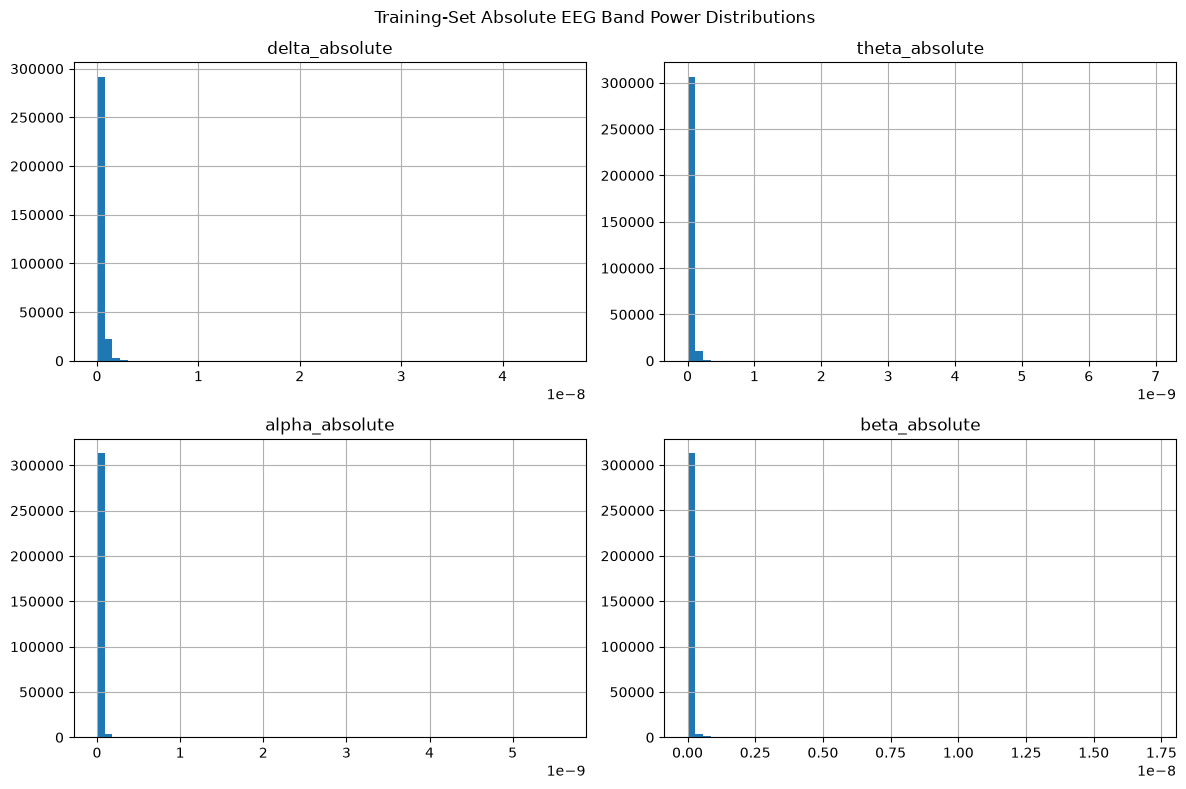

In [29]:
import matplotlib.pyplot as plt

absolute_power_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
]

train_df[
    absolute_power_columns
].hist(
    bins=60,
    figsize=(12, 8),
)

plt.suptitle(
    "Training-Set Absolute EEG Band Power Distributions"
)

plt.tight_layout()

plt.show()

**Log-scale distributions of absolute power**

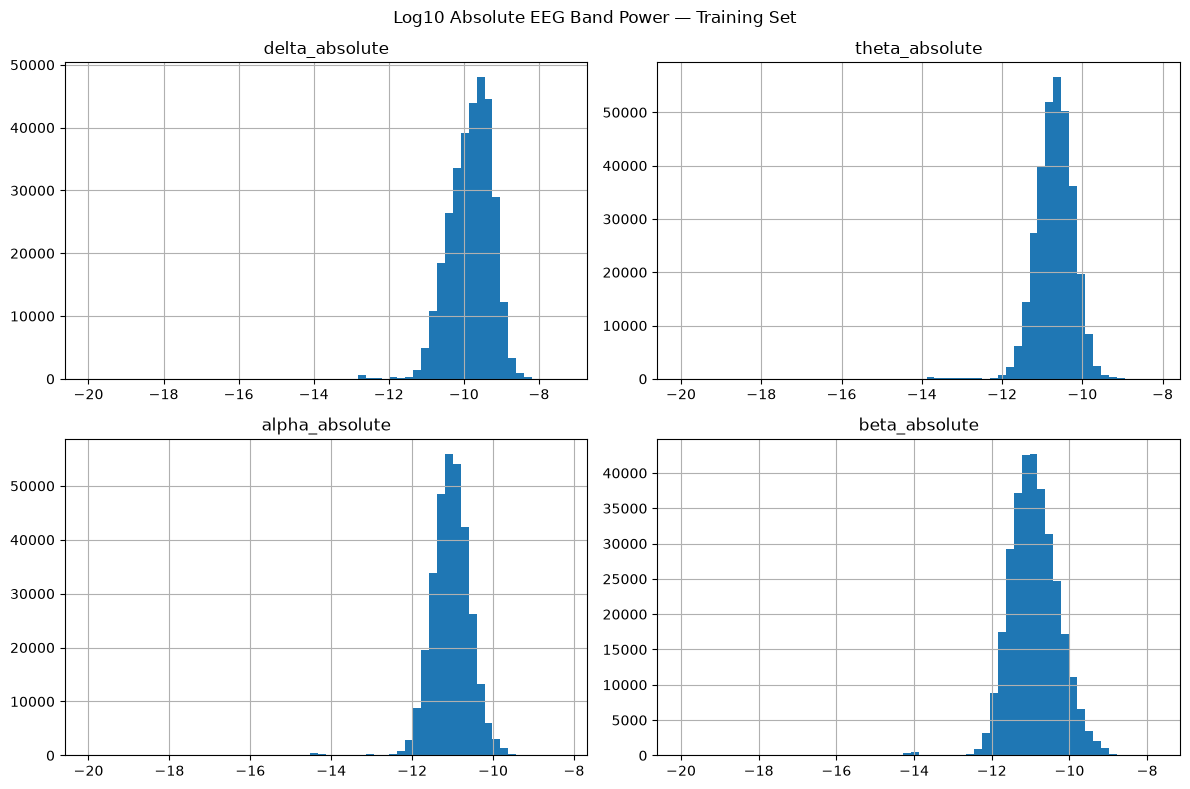

In [30]:
log_power_df = np.log10(
    train_df[
        absolute_power_columns
    ].clip(
        lower=1e-20
    )
)

log_power_df.hist(
    bins=60,
    figsize=(12, 8),
)

plt.suptitle(
    "Log10 Absolute EEG Band Power — Training Set"
)

plt.tight_layout()

plt.show()

**Statistics for relative power, entropy, and dominant frequency**

In [31]:
other_feature_columns = [
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",
    "spectral_entropy",
    "dominant_frequency",
]

display(
    train_df[
        other_feature_columns
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
delta_relative,318821.0,0.737320,0.165222,0.025375,0.658022,0.780997,0.859534,0.999502
theta_relative,318821.0,0.105787,0.050098,0.000485,0.071755,0.097669,0.129282,0.803068
alpha_relative,318821.0,0.058355,0.052337,0.000010,0.024190,0.042447,0.075110,0.776688
beta_relative,318821.0,0.098538,0.107702,0.000003,0.028136,0.059273,0.125879,0.878093
spectral_entropy,318821.0,0.716281,0.099210,0.231170,0.648899,0.709394,0.778890,0.986644
dominant_frequency,318821.0,1.000061,1.182759,0.585938,0.585938,0.781250,1.171875,29.980469


**Compare skewness before and after log transformation**

In [32]:
absolute_power_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
]

log_power_train = np.log10(
    train_df[absolute_power_columns]
)

comparison = pd.DataFrame({
    "raw_skewness": (
        train_df[
            absolute_power_columns
        ].skew()
    ),
    "log10_skewness": (
        log_power_train.skew()
    ),
})

print(
    comparison
)

                raw_skewness  log10_skewness
delta_absolute     14.280451      -14.409224
theta_absolute     40.828218      -19.931358
alpha_absolute     58.722623      -18.861978
beta_absolute      36.202920      -10.642818


In [35]:
from src.preprocessing.normalization import (
    SleepFeatureScaler,
    ALL_FEATURES,
    ABSOLUTE_POWER_FEATURES,
    STANDARD_FEATURES,
)

print("Normalization module imported successfully.")

Normalization module imported successfully.


**Fit the feature scaler using training data only**

In [36]:
feature_scaler = SleepFeatureScaler()

X_train_scaled = (
    feature_scaler.fit_transform(
        train_df
    )
)

print(
    "Scaled training shape:",
    X_train_scaled.shape
)

print(
    "\nTraining means after scaling:"
)

print(
    X_train_scaled.mean()
)

print(
    "\nTraining standard deviations after scaling:"
)

print(
    X_train_scaled.std()
)

Scaled training shape: (318821, 10)

Training means after scaling:
delta_absolute        1.551859e-15
theta_absolute        9.128580e-16
alpha_absolute        1.643144e-15
beta_absolute         8.415410e-16
delta_relative        7.987508e-17
theta_relative       -2.695784e-16
alpha_relative       -3.423218e-17
beta_relative         1.141073e-16
spectral_entropy      7.416971e-17
dominant_frequency   -4.047242e-17
dtype: float64

Training standard deviations after scaling:
delta_absolute        1.000002
theta_absolute        1.000002
alpha_absolute        1.000002
beta_absolute         1.000002
delta_relative        1.000002
theta_relative        1.000002
alpha_relative        1.000002
beta_relative         1.000002
spectral_entropy      1.000002
dominant_frequency    1.000002
dtype: float64


**Transform validation and test using the training scaler**

In [37]:
X_val_scaled = (
    feature_scaler.transform(
        val_df
    )
)

X_test_scaled = (
    feature_scaler.transform(
        test_df
    )
)

print(
    "Validation shape:",
    X_val_scaled.shape
)

print(
    "Test shape:",
    X_test_scaled.shape
)

Validation shape: (69567, 10)
Test shape: (68252, 10)


**Check scaled feature ranges**

In [38]:
scaled_train_df = pd.DataFrame(
    X_train_scaled,
    columns=ALL_FEATURES,
)

scaled_val_df = pd.DataFrame(
    X_val_scaled,
    columns=ALL_FEATURES,
)

scaled_test_df = pd.DataFrame(
    X_test_scaled,
    columns=ALL_FEATURES,
)

print("Training summary:")
display(
    scaled_train_df.describe().T[
        ["mean", "std", "min", "max"]
    ]
)

Training summary:


,mean,std,min,max
delta_absolute,1.551859e-15,1.000002,-54.563235,3.707295
theta_absolute,9.128580e-16,1.000002,-61.180917,4.286737
alpha_absolute,1.643144e-15,1.000002,-60.226038,4.695763
beta_absolute,8.415410e-16,1.000002,-49.843155,4.436331
delta_relative,7.987508e-17,1.000002,-4.309025,1.586852
theta_relative,-2.695784e-16,1.000002,-2.101946,13.918409
alpha_relative,-3.423218e-17,1.000002,-1.114785,13.725089
beta_relative,1.141073e-16,1.000002,-0.914889,7.238105
spectral_entropy,7.416971e-17,1.000002,-4.889772,2.725171
dominant_frequency,-4.047242e-17,1.000002,-0.350134,24.502420


**Verify scaler isolation**

In [39]:
print("Training scaled means:")
print(
    scaled_train_df.mean().round(6)
)

print("\nValidation scaled means:")
print(
    scaled_val_df.mean().round(6)
)

print("\nTest scaled means:")
print(
    scaled_test_df.mean().round(6)
)

Training scaled means:
delta_absolute        0.0
theta_absolute        0.0
alpha_absolute        0.0
beta_absolute         0.0
delta_relative        0.0
theta_relative       -0.0
alpha_relative       -0.0
beta_relative         0.0
spectral_entropy      0.0
dominant_frequency   -0.0
dtype: float64

Validation scaled means:
delta_absolute        0.061953
theta_absolute        0.080320
alpha_absolute        0.106025
beta_absolute         0.056430
delta_relative        0.023347
theta_relative        0.043217
alpha_relative        0.041507
beta_relative        -0.076089
spectral_entropy     -0.021178
dominant_frequency   -0.039081
dtype: float64

Test scaled means:
delta_absolute       -0.030371
theta_absolute       -0.045823
alpha_absolute       -0.057475
beta_absolute        -0.066817
delta_relative        0.069915
theta_relative        0.057159
alpha_relative       -0.049430
beta_relative        -0.109822
spectral_entropy     -0.026820
dominant_frequency   -0.038937
dtype: float64
